# ATTAG: Train all GNN models and plot embedding-clustering quality

`train()` in `embedding/train.py` already computes, for every model, the clustering metrics of the learned node embeddings and saves them in `<model>_info.pt`. This notebook

1. trains every model with the same data, seed and settings (or reuses finished runs),
2. **reads the metrics `train()` saved** instead of recomputing anything,
3. plots the three-panel bar figure: **(a) Silhouette Score, (b) Davies-Bouldin Index, (c) ARI Stability**,
4. writes one CSV with the clustering metrics and the test classification metrics.

### Where each number comes from (all inside `train()`)

| Figure / column | Definition in `train()` |
|---|---|
| Silhouette Score (`silhouette`) | `silhouette_score(trained_embeddings, trained_clusters)` on the training graph |
| Davies-Bouldin Index (`davies_bouldin`) | `davies_bouldin_score(trained_embeddings, trained_clusters)` |
| ARI Stability (`ari_stability`) | `adjusted_rand_score(initial_clusters, trained_clusters)`: agreement between the clusters of the **untrained** network's embeddings and the **trained** ones |
| `test_*`, `best_val_auprc` | `info["test_metrics"]`, `info["best_val_auprc"]` |

The clusters come from the project's own `calculate_cluster_labels(net, loader, device)`; one cell below prints its source so you can state the clustering method and `k` in the paper.

> The networks are trained as node classifiers on the binary `significance` label (not on driver genes), so these are properties of embeddings trained for that task.

In [ ]:
from pathlib import Path
import sys 
import os
import json
import time
import random
import shutil
import warnings
import traceback
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

import torch

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
embedding_dir = next((p for p in [cwd, cwd / "embedding"] if (p / "train.py").is_file()), None)
if embedding_dir is None:
    raise FileNotFoundError(
        "Could not find train.py. Run this notebook from the ATTAG repository "
        "root or from the embedding directory."
    )
if str(embedding_dir) not in sys.path:
    sys.path.insert(0, str(embedding_dir))

import train as embedding_train

print(f"Embedding module : {embedding_dir}")
print(f"PyTorch          : {torch.__version__}")
print(f"train.train sig  : {inspect.signature(embedding_train.train)}")

Embedding module : /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/embedding
PyTorch          : 2.3.1
train.train sig  : (hyperparams=None, data_path='data/emb', plot=True)


## 1. Configuration

In [24]:
DATA_PATH = "data/emb"

# Order here = order of the bars in the figure.
MODEL_TYPES = ["gat", "gcn", "graphsage", "chebnet", "gin"]

DISPLAY_NAMES = {
    "gat": "GAT", "gcn": "GCN", "graphsage": "GraphSAGE",
    "chebnet": "ChebNet", "gin": "GIN",
}

# BASE_CONFIG = {
#     "num_epochs": 100,          # your latest runs used 100 (checkpoint names contain epo100)
#     "in_feats": 2,
#     "out_feats": 128,
#     "num_layers": 2,
#     "num_heads": 1,
#     "lr": 1e-3,
#     "batch_size": 1,
#     "device": "cuda" if torch.cuda.is_available() else "cpu",
#     "seed": 42,
#     "val_size": 0.20,
#     "patience": 10,
#     "min_delta": 1e-5,
#     "grad_clip": 1.0,
#     "lr_factor": 0.5,
#     "lr_patience": 8,
#     "min_lr": 1e-7,
#     "threshold": 0.5,
#     "negative_weight": 1e-5,
#     "positive_weight": 0.99999,
# }


WEIGHT_SEED = 42

# Draw a random pair of positive class weights that sum to 1.
# The fixed seed makes the pair reproducible.
_random_class_weights = np.random.default_rng(WEIGHT_SEED).dirichlet([1.0, 1.0])

BASE_CONFIG = {
    "num_epochs": 100,
    "in_feats": 2,
    "out_feats": 128,
    "num_layers": 2,
    "num_heads": 1,
    "lr": 1e-3,
    "batch_size": 1,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": WEIGHT_SEED,
    "val_size": 0.20,
    "patience": 10,
    "min_delta": 1e-5,
    "grad_clip": 1.0,
    "lr_factor": 0.5,
    "lr_patience": 8,
    "min_lr": 1e-7,
    "threshold": 0.5,
    "negative_weight": float(_random_class_weights[0]),
    "positive_weight": float(_random_class_weights[1]),
}

print("Class weights:", {
    "negative_weight": BASE_CONFIG["negative_weight"],
    "positive_weight": BASE_CONFIG["positive_weight"],
})


PLOT_DURING_TRAINING = True

# True : reuse a model whose summary.json says "success" AND whose saved config matches
#        BASE_CONFIG (a changed setting triggers retraining of that model).
# False: retrain everything.
SKIP_COMPLETED = False

SMOKE_TEST = False
if SMOKE_TEST:
    BASE_CONFIG["num_epochs"] = 5
    BASE_CONFIG["patience"] = 3

MODEL_ROOT = Path(DATA_PATH) / "models" / "all_models"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

# Figure style
MARK_DIRECTION = True       # adds an up arrow to Silhouette and a down arrow to Davies-Bouldin
BAR_COLOR, BAR_WIDTH = "#CFFFD5", 0.35

print("MODEL_ROOT:", MODEL_ROOT.resolve())
print("MODELS    :", MODEL_TYPES)
print("EPOCHS    :", BASE_CONFIG["num_epochs"])

Class weights: {'negative_weight': 0.5071743917297519, 'positive_weight': 0.4928256082702482}
MODEL_ROOT: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb/models/all_models
MODELS    : ['gat', 'gcn', 'graphsage', 'chebnet', 'gin']
EPOCHS    : 100


## 2. Helpers

In [25]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


def make_hyperparams(model_type: str):
    hp = dict(BASE_CONFIG)
    hp["model_type"] = model_type
    return hp


def model_output_dir(model_type: str):
    path = MODEL_ROOT / model_type
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_json(obj, path):
    def convert(x):
        if isinstance(x, Path):
            return str(x)
        if isinstance(x, np.integer):
            return int(x)
        if isinstance(x, np.floating):
            return float(x)
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().tolist()
        return x

    path.write_text(json.dumps(obj, indent=2, default=convert), encoding="utf-8")


def completed_summary_path(model_type):
    return model_output_dir(model_type) / "summary.json"


def flatten_result(result):
    if result is None:
        return {}
    if isinstance(result, dict):
        return result
    return {"return_value": str(result)}


def resolve_path(p):
    """Resolve a (possibly relative) path returned by train() to an existing file."""
    if p is None:
        return None
    p = Path(str(p))
    for base in (Path.cwd(), embedding_dir, embedding_dir.parent):
        cand = p if p.is_absolute() else base / p
        if cand.is_file():
            return cand.resolve()
    return None


def same_config(model_type):
    """True if config.json of the previous run matches the current settings."""
    try:
        old = json.loads((model_output_dir(model_type) / "config.json").read_text())["hyperparams"]
    except Exception:
        return False
    new = make_hyperparams(model_type)
    return all(old.get(k) == new.get(k) for k in new if k != "device")

## 3. What the project's clustering step does

`train()` clusters the embeddings with `calculate_cluster_labels`. Its source is printed here so the clustering method and number of clusters used for Silhouette / Davies-Bouldin / ARI are on record.

In [26]:
fn = getattr(embedding_train, "calculate_cluster_labels", None)
if fn is None:
    print("calculate_cluster_labels is not exposed by train.py (check where it is imported from).")
else:
    try:
        print(inspect.getsource(fn))
    except Exception as exc:
        print("Could not read the source:", exc, "\nDefined in:", getattr(fn, "__module__", "?"))

def create_heatmap_with_stid(embedding_list, stid_list, save_path):
    """
    Creates a heatmap with hierarchical clustering using 10 discrete colors.

    Parameters:
    - embedding_list: List of embeddings.
    - stid_list: List of sample or feature IDs corresponding to embeddings.
    - save_path: Path to save the heatmap.
    """
    # Convert the embedding list to a DataFrame and transpose it
    heatmap_data = pd.DataFrame(embedding_list, index=stid_list).transpose()
    ##heatmap_data = pd.DataFrame(embedding_list, index=stid_list)

    # Define 10 discrete colors
    discrete_colors = [
        '#f7fcf0', '#e0f3db', '#ccebc5', '#a8ddb5', '#7bccc4',
        '#4eb3d3', '#2b8cbe', '#0868ac', '#084081', '#081d58'
    ]  # Gradient from light green to dark blue

    # Define value ranges (bins) for the colors
    color_bounds = np.linspace(heatmap_data.min().min(), heatmap_data.max().max(), len(discrete_colors) + 1)

    # Create a discrete colormap and norm
    cmap = ListedColo

## 4. Train every model

`train()` returns the path of the `.pth` state_dict and also writes `<same name>_info.pt` next to it (best epoch, validation/test metrics, clustering metrics). After each successful run both files are copied into `MODEL_ROOT/<model>/` so every model's artifacts are kept together. Checkpoint names contain the model type, so models cannot overwrite each other.

In [27]:
run_records = []

for model_type in MODEL_TYPES:
    print("\n" + "=" * 80)
    print(f"STARTING MODEL: {model_type}")
    print("=" * 80)

    set_seed(int(BASE_CONFIG["seed"]))

    output_dir = model_output_dir(model_type)
    summary_path = completed_summary_path(model_type)

    if SKIP_COMPLETED and summary_path.exists():
        try:
            existing = json.loads(summary_path.read_text(encoding="utf-8"))
            if existing.get("status") == "success":
                if same_config(model_type):
                    print(f"Skipping completed model: {model_type}")
                    run_records.append(existing)
                    continue
                print("Saved config differs from the current BASE_CONFIG -> retraining.")
        except Exception:
            pass

    hyperparams = make_hyperparams(model_type)
    save_json(
        {"model_type": model_type, "hyperparams": hyperparams,
         "data_path": str(Path(DATA_PATH).resolve()), "output_dir": str(output_dir.resolve())},
        output_dir / "config.json",
    )

    start = time.perf_counter()
    record = {"model_type": model_type, "status": "running", "elapsed_seconds": np.nan,
              "model_output_dir": str(output_dir.resolve())}

    try:
        result = embedding_train.train(
            hyperparams=hyperparams, data_path=DATA_PATH, plot=PLOT_DURING_TRAINING
        )
        elapsed = time.perf_counter() - start
        record.update(flatten_result(result))
        record.update(model_type=model_type, status="success", elapsed_seconds=elapsed)

        model_path = resolve_path(result) if isinstance(result, (str, Path)) else None
        if model_path is not None:
            info_path = resolve_path(str(model_path)[:-4] + "_info.pt") if str(model_path).endswith(".pth") else None
            for src in (model_path, info_path):
                if src is not None:
                    shutil.copy2(src, output_dir / src.name)
            record["model_path"] = str(model_path)
            record["info_path"] = str(info_path) if info_path else ""
        else:
            print("WARNING: train() did not return an existing file path.")

        save_json(record, summary_path)
        print(f"SUCCESS: {model_type}  ({elapsed / 60:.2f} min)")

    except KeyboardInterrupt:
        record.update(status="interrupted", error="KeyboardInterrupt",
                      elapsed_seconds=time.perf_counter() - start)
        save_json(record, summary_path)
        raise

    except Exception as exc:
        record.update(status="failed", error=repr(exc), traceback=traceback.format_exc(),
                      elapsed_seconds=time.perf_counter() - start)
        save_json(record, summary_path)
        print(f"FAILED: {model_type}\nError: {exc}\nContinuing with the next model.")
        if isinstance(exc, NameError):
            print("HINT: train.py/model.py refers to a name that is not defined or imported "
                  "(e.g. returnGCNModel). Fix the import, then rerun this cell; failed models are retried.")

    run_records.append(record)

run_df = pd.DataFrame(run_records)
cols = [c for c in ["model_type", "status", "elapsed_seconds", "return_value", "error"] if c in run_df.columns]
display(run_df[cols])
run_df.to_csv(MODEL_ROOT / "training_run_summary.csv", index=False)


STARTING MODEL: gat
Dataset root:     /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb
Raw directory:    /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb/raw
Processed dir:    /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb/processed
Model directory:  /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb/models
Processed graph 1: emb_test.pkl -> /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb/processed/emb_test.dgl
Processed graph 2: emb_train.pkl -> /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/data/emb/processed/emb_train.dgl
Training graph nodes: 4025
Training nodes: 3220 (80.00%)
Validation nodes: 805 (20.00%)
Class distribution: {0: 407, 1: 3618}

Creating model
model_type: gat
in_feats: 2
out_feats: 128
num_layers: 2

,model_type,status,elapsed_seconds,return_value
0,gat,success,152.823421,data/emb/models/model_head1_dim128_lay2_epo100...
1,gcn,success,86.907910,data/emb/models/model_head1_dim128_lay2_epo100...
2,graphsage,success,87.010812,data/emb/models/model_head1_dim128_lay2_epo100...
3,chebnet,success,85.170882,data/emb/models/model_head1_dim128_lay2_epo100...
4,gin,success,82.862222,data/emb/models/model_head1_dim128_lay2_epo100...


## 5. Collect the metrics saved by `train()`

Reads each model's `*_info.pt` and extracts `info["clustering_metrics"]` (initial and trained Silhouette / Davies-Bouldin and the initial-vs-trained ARI), `info["test_metrics"]`, `best_epoch` and `best_val_auprc`. Nothing is recomputed. A model that is missing a file or a key is reported with its reason instead of being silently dropped.

In [28]:
def _load_info(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _f(x):
    try:
        return float(x)
    except Exception:
        return np.nan


metric_rows = []

for m in MODEL_TYPES:
    row = {
        "model_type": m, "status": "failed", "error": "",
        "silhouette": np.nan, "davies_bouldin": np.nan, "ari_stability": np.nan,
        "initial_silhouette": np.nan, "initial_davies_bouldin": np.nan,
        "silhouette_change": np.nan, "davies_bouldin_change": np.nan,
        "best_epoch": np.nan, "epochs_trained": np.nan, "best_val_auprc": np.nan,
        "test_auroc": np.nan, "test_auprc": np.nan, "test_f1": np.nan,
        "test_accuracy": np.nan, "test_precision": np.nan, "test_recall": np.nan,
        "test_loss": np.nan, "info_source": "",
    }
    try:
        sp = completed_summary_path(m)
        rec = json.loads(sp.read_text(encoding="utf-8")) if sp.exists() else {}
        if rec.get("status") != "success":
            raise RuntimeError(f"training status = {rec.get('status', 'missing')}: {rec.get('error', '')}")

        mp = resolve_path(rec.get("model_path") or rec.get("return_value"))
        ip = resolve_path(str(mp)[:-4] + "_info.pt") if (mp is not None and str(mp).endswith(".pth")) else None
        if ip is None:   # fall back to the copy kept in the model folder
            ip = next(iter(sorted(model_output_dir(m).glob("*_info.pt"))), None)
        if ip is None:
            raise FileNotFoundError("no *_info.pt found (expected next to the .pth returned by train())")

        info = _load_info(ip)
        cm = info.get("clustering_metrics")
        if cm is None:
            raise KeyError("info has no 'clustering_metrics' (train() stopped before saving them)")
        tm = info.get("test_metrics", {}) or {}

        row.update(
            status="success",
            silhouette=_f(cm["trained"]["silhouette"]),
            davies_bouldin=_f(cm["trained"]["davies_bouldin"]),
            ari_stability=_f(cm["ari_initial_vs_trained"]),
            initial_silhouette=_f(cm["initial"]["silhouette"]),
            initial_davies_bouldin=_f(cm["initial"]["davies_bouldin"]),
            silhouette_change=_f(cm["change"]["silhouette"]),
            davies_bouldin_change=_f(cm["change"]["davies_bouldin"]),
            best_epoch=_f(info.get("best_epoch")),
            epochs_trained=float(len(info.get("history", []))),
            best_val_auprc=_f(info.get("best_val_auprc")),
            test_auroc=_f(tm.get("auroc")), test_auprc=_f(tm.get("auprc")), test_f1=_f(tm.get("f1")),
            test_accuracy=_f(tm.get("accuracy")), test_precision=_f(tm.get("precision")),
            test_recall=_f(tm.get("recall")), test_loss=_f(tm.get("loss")),
            info_source=str(ip),
        )
    except Exception as exc:
        row["error"] = repr(exc)
        print(f"{m}: {exc}")

    metric_rows.append(row)

clustering_df = pd.DataFrame(metric_rows)
display(clustering_df[["model_type", "status", "silhouette", "davies_bouldin", "ari_stability",
                       "best_epoch", "epochs_trained", "best_val_auprc",
                       "test_auroc", "test_auprc", "test_f1"]])

csv_path = MODEL_ROOT / "clustering_metrics_all_models.csv"
clustering_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

,model_type,status,silhouette,davies_bouldin,ari_stability,best_epoch,epochs_trained,best_val_auprc,test_auroc,test_auprc,test_f1
0,gat,success,0.165639,3.267464,0.266435,26.0,36.0,0.948819,0.655863,0.866547,0.887968
1,gcn,success,0.538671,0.506772,0.998954,1.0,11.0,0.819176,0.293450,0.681752,0.729967
2,graphsage,success,0.520283,1.077286,0.655626,9.0,19.0,0.947924,0.707461,0.882961,0.887968
3,chebnet,success,0.550500,0.508189,0.799336,1.0,11.0,0.819176,0.293450,0.681752,0.887968
4,gin,success,0.567811,0.495142,1.000000,6.0,16.0,0.908392,0.537475,0.810345,0.005580


Saved: data/emb/models/all_models/clustering_metrics_all_models.csv


## 6. Three-panel bar figure

Layout of the reference figure: (a) Silhouette Score, (b) Davies-Bouldin Index, (c) ARI Stability; light-green bars, two-decimal labels, 0-1 y-axis (extended automatically if a value exceeds 1), 45-degree model names, serif font. Saved as PNG (300 dpi), PDF and SVG.

`MARK_DIRECTION` adds an up arrow to Silhouette and a down arrow to Davies-Bouldin (lower is better). ARI Stability has no arrow on purpose: it measures agreement between the untrained and trained clusterings, so a *low* value means training reorganised the clusters and a *high* value means the structure was already present before training. Describe it that way in the text.

Saved: results/clustering_metrics_3panel.png
Saved: results/clustering_metrics_3panel.pdf
Saved: results/clustering_metrics_3panel.svg


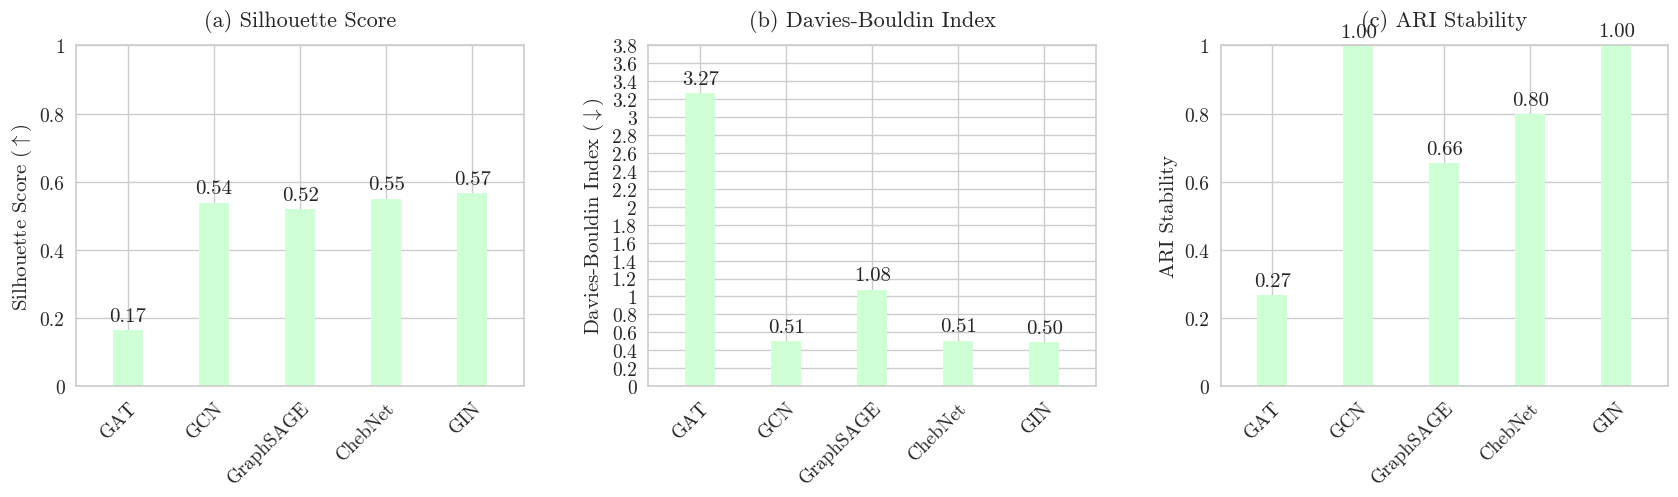

In [29]:
PLOT_DIR = Path("results")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def set_paper_style():
    plt.rcParams.update({
        "font.family": "serif", "font.serif": ["cmr10", "DejaVu Serif"],
        "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,
        "axes.unicode_minus": False, "font.size": 14, "axes.titlesize": 16,
        "axes.labelsize": 15, "xtick.labelsize": 14, "ytick.labelsize": 14,
    })


def draw_panel(ax, names, vals, title, ylabel):
    vals = np.asarray(vals, dtype=float)
    x = np.arange(len(names))
    fmax = np.nanmax(vals) if np.isfinite(vals).any() else 1.0
    top = 1.0 if fmax <= 1.0 else float(np.ceil(fmax * 1.15 * 5) / 5)

    ax.bar(x, np.nan_to_num(vals, nan=0.0), width=BAR_WIDTH, color=BAR_COLOR, linewidth=0)
    ax.set_ylim(0, top)
    ax.set_xlim(-0.6, len(names) - 0.4)
    ax.set_yticks(np.arange(0, top + 1e-9, 0.2))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="both", direction="out", length=5, width=1.2)
    ax.set_title(title, pad=14)
    ax.set_ylabel(ylabel)
    for xi, v in zip(x, vals):
        if np.isfinite(v):
            ax.text(xi, v + 0.015 * top, f"{v:.2f}", ha="center", va="bottom", fontsize=15)
    for s in ax.spines.values():
        s.set_linewidth(1.2)


def plot_clustering_panels(df, stem="clustering_metrics_3panel"):
    ok = df[df["status"] == "success"].set_index("model_type")
    order = [m for m in MODEL_TYPES if m in ok.index]
    if not order:
        print("No successful models to plot. Reasons:")
        print(df[["model_type", "status", "error"]].to_string(index=False))
        return None
    names = [DISPLAY_NAMES.get(m, m) for m in order]

    up = r" ($\uparrow$)" if MARK_DIRECTION else ""
    down = r" ($\downarrow$)" if MARK_DIRECTION else ""

    set_paper_style()
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
    draw_panel(axes[0], names, ok.loc[order, "silhouette"].values,
               "(a) Silhouette Score", "Silhouette Score" + up)
    draw_panel(axes[1], names, ok.loc[order, "davies_bouldin"].values,
               "(b) Davies-Bouldin Index", "Davies-Bouldin Index" + down)
    draw_panel(axes[2], names, ok.loc[order, "ari_stability"].values,
               "(c) ARI Stability", "ARI Stability")
    fig.tight_layout(w_pad=3)

    for ext, kw in (("png", {"dpi": 300}), ("pdf", {}), ("svg", {})):
        p = PLOT_DIR / f"{stem}.{ext}"
        fig.savefig(p, bbox_inches="tight", **kw)
        print("Saved:", p)
    plt.show()
    return fig


_ = plot_clustering_panels(clustering_df)